In [25]:
from google.colab import userdata


In [26]:
!pip install roboflow
from roboflow import Roboflow

rf = Roboflow(api_key=userdata.get('ROBO_FLOW_API_KEY'))

project = rf.workspace("beshoy-karam").project("american-language-9cogc")
version = project.version(1)

dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to American-Language-1 in yolov11:: 100%|██████████| 16319/16319 [00:01<00:00, 9597.95it/s] 


In [27]:
!pip install -U ultralytics

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [28]:
dataset = version.download("yolov11")

In [29]:
import os

print(dataset.location)
print(os.listdir(dataset.location))

/content/American-Language-1
['README.roboflow.txt', 'train', 'valid', 'data.yaml', 'README.dataset.txt', 'test']


In [30]:
data_yaml = f"{dataset.location}/data.yaml"

print(data_yaml)

/content/American-Language-1/data.yaml


In [31]:
results = model.train(
    data=data_yaml,
    epochs=30,
    imgsz=512,
    batch=8,
    device="cuda",
    patience=10,
    project="asl_training",
    name="yolo11n_asl"
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/American-Language-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_asl-5, nbs=64, 

In [33]:
best_model = YOLO(
    "/content/runs/detect/asl_training/yolo11n_asl-5/weights/best.pt"
)

In [34]:
import os

for root, dirs, files in os.walk("/content"):
    if "best.pt" in files:
        print(os.path.join(root, "best.pt"))

/content/runs/detect/asl_training/yolo11n_asl-5/weights/best.pt


In [35]:
metrics = best_model.val(
    data=data_yaml,
    device="cuda"
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,587,222 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 673.9±212.1 MB/s, size: 19.4 KB)
val: Scanning /content/American-Language-1/valid/labels.cache... 680 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 680/680 237.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 6.3it/s 6.9s
                   all        680        680       0.99      0.992      0.991      0.844
                     0         26         26      0.996          1      0.995      0.896
                     1         21         21          1      0.966      0.995      0.835
                    10         24         24      0.958          1      0.972      0.809
                    11         30         30      0.993          1      0.995      0.869
                    12         26

In [42]:
results = best_model.predict(
    source="/content/American-Language-1/valid/images/E-4-_jpeg.rf.668e2643ba432125a3b48681fa5c222b.jpg",
    conf=0.5,
    device="cuda",
    save=True
)


image 1/1 /content/American-Language-1/valid/images/E-4-_jpeg.rf.668e2643ba432125a3b48681fa5c222b.jpg: 512x512 1 4, 28.3ms
Speed: 5.0ms preprocess, 28.3ms inference, 4.1ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/runs/detect/predict


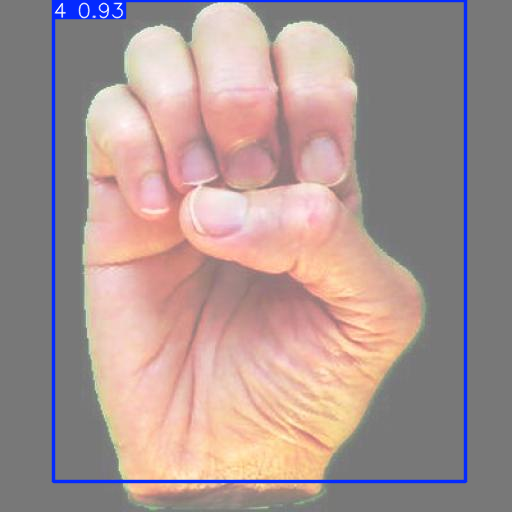

In [43]:
from IPython.display import display
from PIL import Image

result_image = results[0].plot()

display(Image.fromarray(result_image[..., ::-1]))

In [41]:
print(best_model.names)

{0: '0', 1: '1', 2: '10', 3: '11', 4: '12', 5: '13', 6: '14', 7: '15', 8: '16', 9: '17', 10: '18', 11: '19', 12: '2', 13: '20', 14: '21', 15: '22', 16: '23', 17: '24', 18: '25', 19: '3', 20: '4', 21: '5', 22: '6', 23: '7', 24: '8', 25: '9'}
